=== Loaded series ===
FX pairs: ['EURUSD', 'GBPUSD', 'USDJPY', 'GBPJPY', 'EURGBP', 'EURJPY', 'USDCHF']
Date range: 2018-01-01 00:00:00 → 2026-02-16 00:00:00

=== Missing values per pair (raw) ===
EURUSD     209
GBPUSD     209
USDJPY     209
GBPJPY    1330
EURGBP     209
EURJPY     209
USDCHF     209
dtype: int64
Total missing: 2584

=== After alignment (dropna across all pairs) ===
Rows: 791 | Columns: 7
Any NA left? False

=== Returns quick stats ===
            mean       std       min       max
EURUSD  0.000126  0.004420 -0.018647  0.021546
GBPUSD  0.000159  0.004459 -0.016302  0.017655
USDJPY  0.000185  0.006098 -0.022678  0.020615
GBPJPY  0.000344  0.005605 -0.021138  0.022828
EURGBP -0.000033  0.002798 -0.009325  0.012196
EURJPY  0.000311  0.005305 -0.021446  0.018015
USDCHF -0.000238  0.005059 -0.038661  0.020952

=== Outliers on log-returns (|z| > 4.0) ===
EURUSD: 3 outliers (showing last 5)
2024-11-06   -0.018647
2025-04-03    0.020488
2025-04-10    0.021546
Name: EURUSD, dtyp

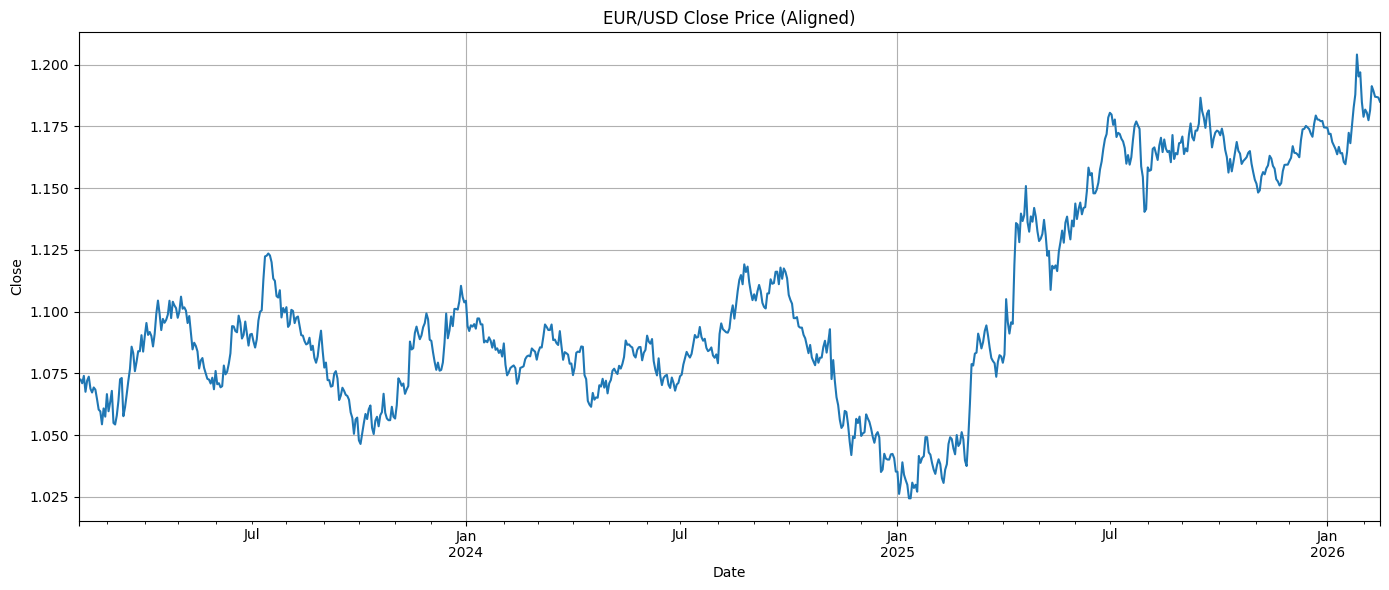

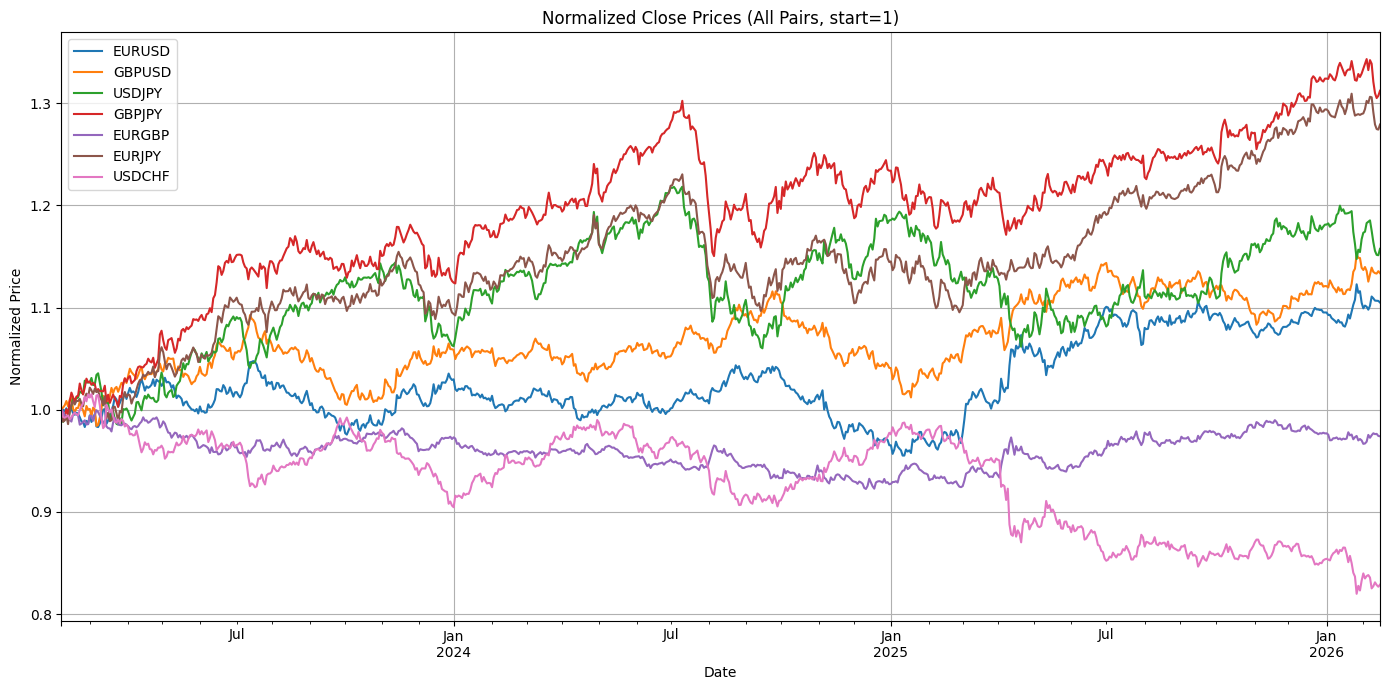

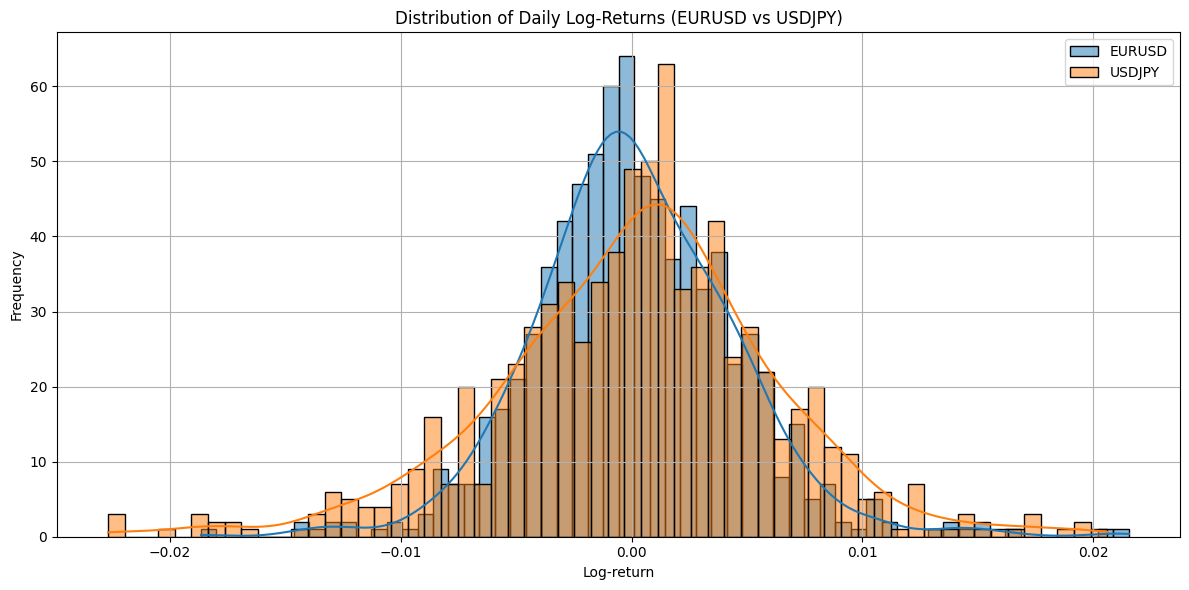

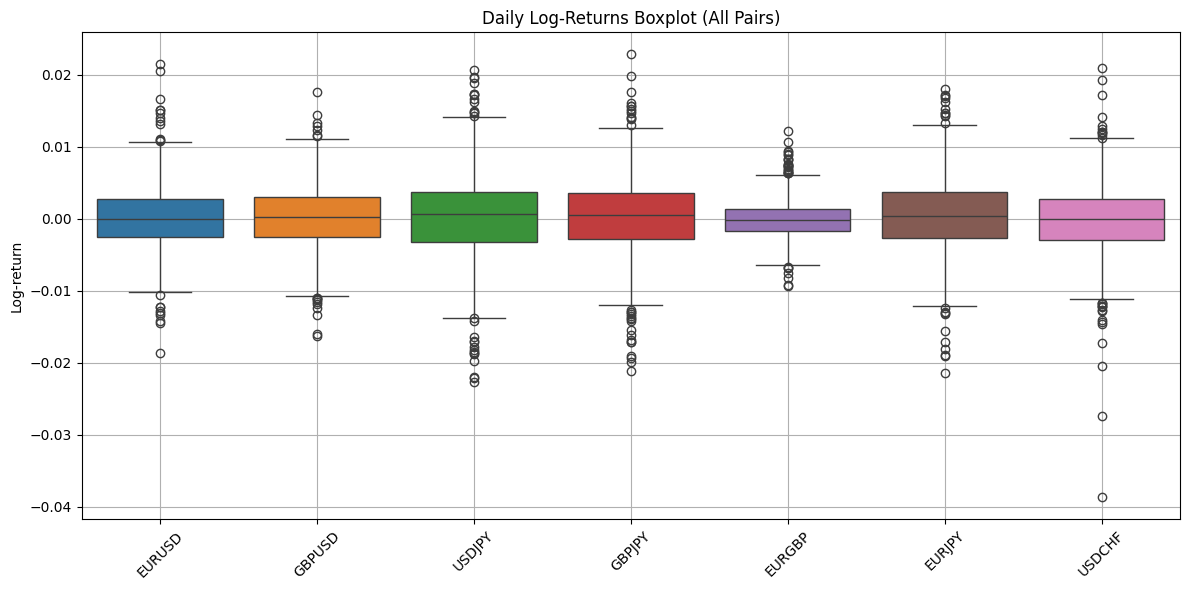


=== Static correlation (Pearson on log-returns) ===
        EURUSD  GBPUSD  USDJPY  GBPJPY  EURGBP  EURJPY  USDCHF
EURUSD   1.000   0.799  -0.531   0.058   0.305   0.222  -0.790
GBPUSD   0.799   1.000  -0.472   0.282  -0.325   0.123  -0.629
USDJPY  -0.531  -0.472   1.000   0.713  -0.091   0.707   0.602
GBPJPY   0.058   0.282   0.713   1.000  -0.357   0.867   0.155
EURGBP   0.305  -0.325  -0.091  -0.357   1.000   0.152  -0.249
EURJPY   0.222   0.123   0.707   0.867   0.152   1.000   0.033
USDCHF  -0.790  -0.629   0.602   0.155  -0.249   0.033   1.000


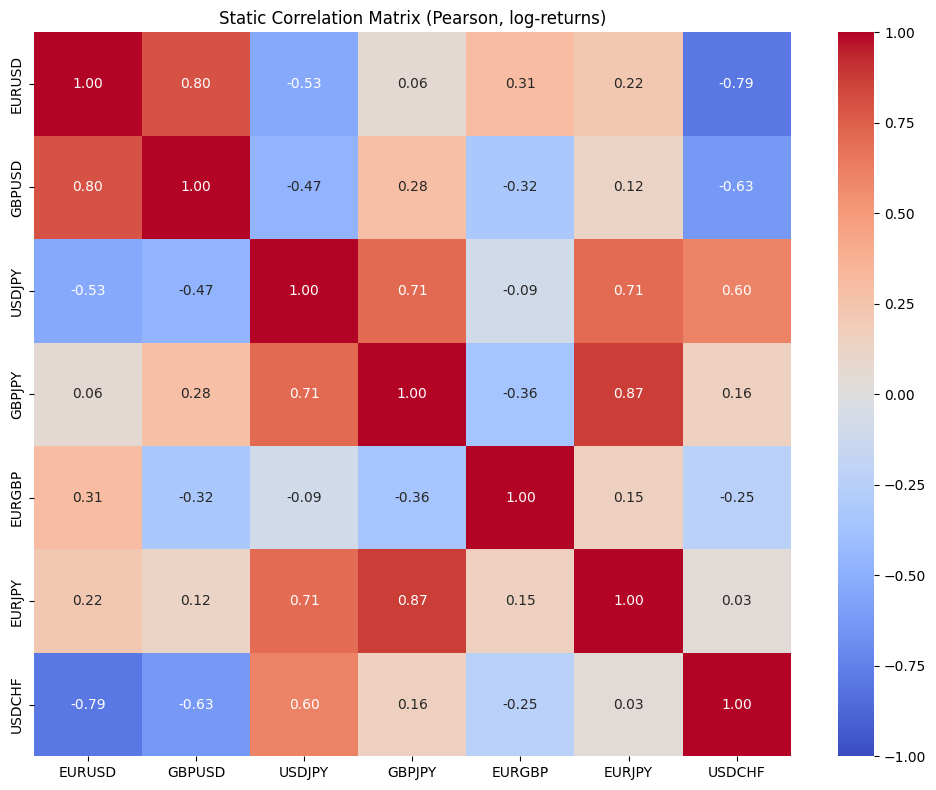

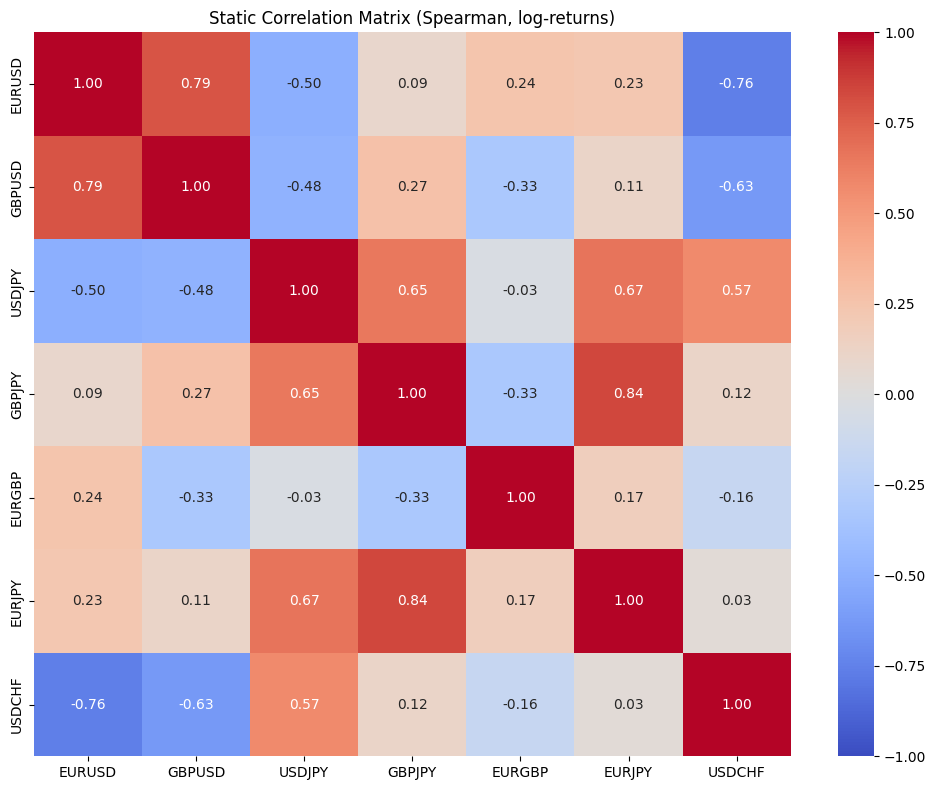

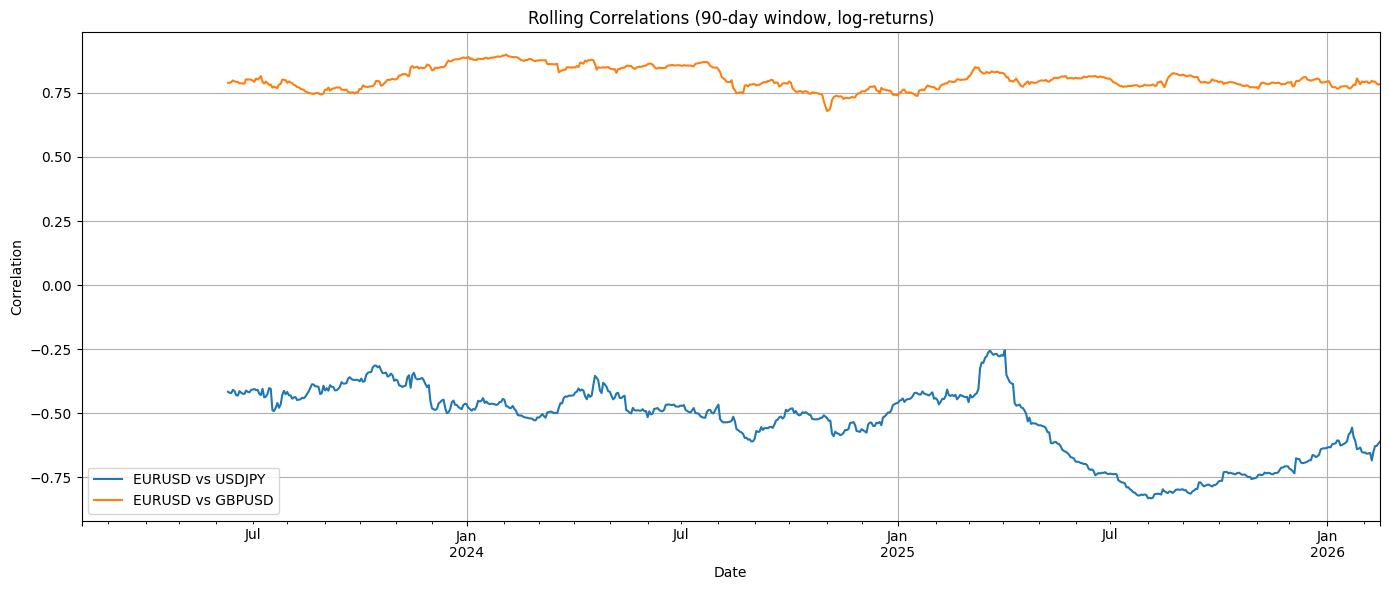

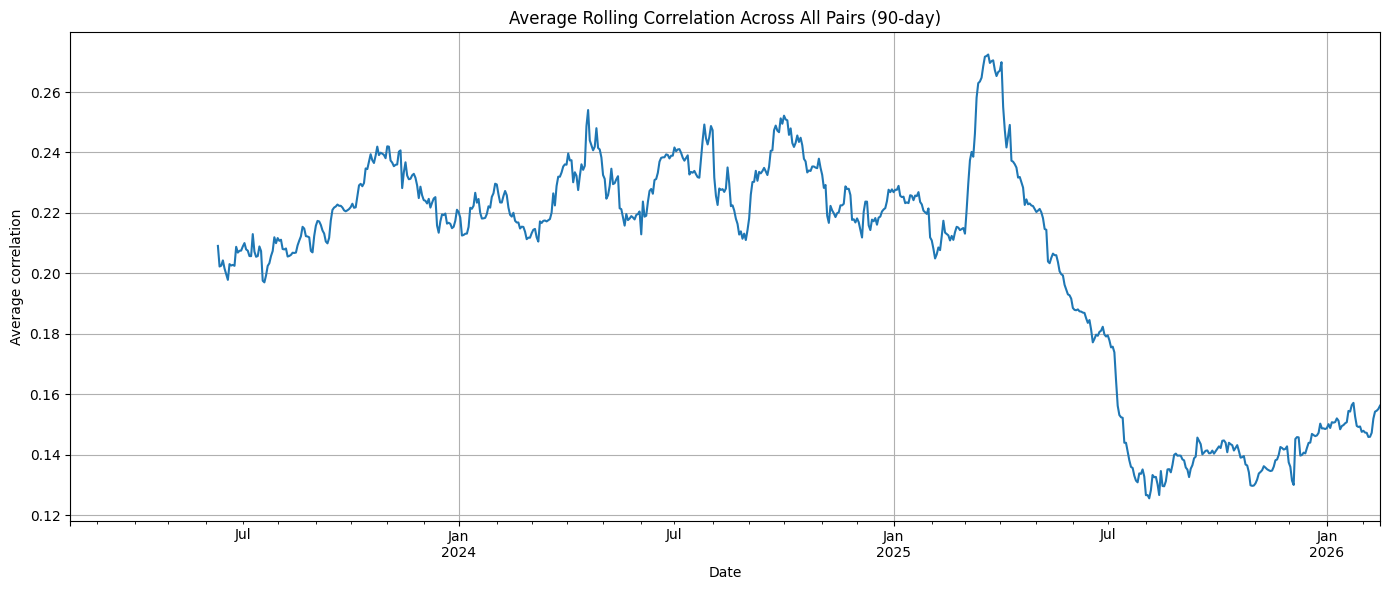


=== Correlation breakdown alerts (EURUSD vs GBPUSD) ===
Series([], dtype: float64)


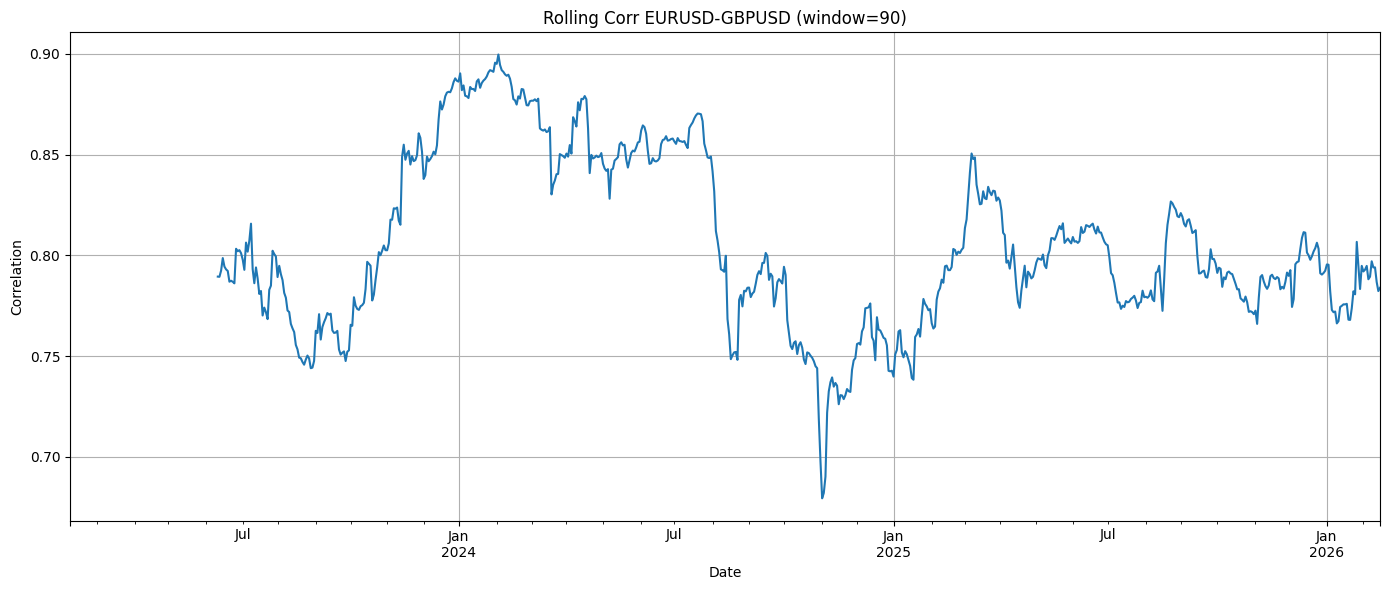

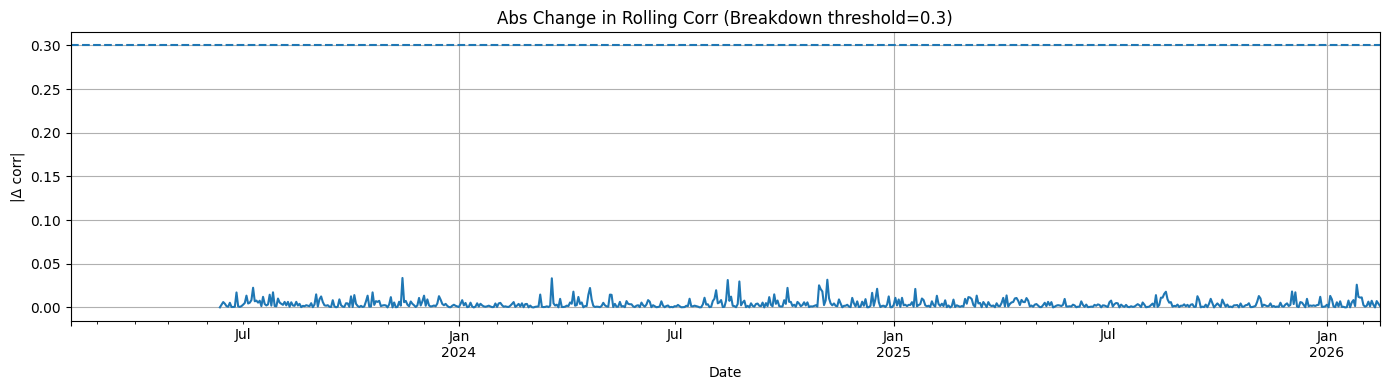


=== ADF Stationarity Test (log-returns) ===
     name   adf_stat  p_value  stationary_5pct
0  EURUSD -28.858549      0.0             True
1  GBPUSD -28.394943      0.0             True
2  USDJPY -28.034093      0.0             True
3  GBPJPY -28.542490      0.0             True
4  EURGBP -21.495733      0.0             True
5  EURJPY -28.664089      0.0             True
6  USDCHF -29.091381      0.0             True

=== Correlation Agent Output (summary) ===
{'timestamp': '2026-02-16', 'agent': 'correlation_agent', 'pairs_used': ['EURUSD', 'GBPUSD', 'USDJPY', 'GBPJPY', 'EURGBP', 'EURJPY', 'USDCHF'], 'data_points_after_alignment': 790, 'rolling_window_days': 90, 'top_correlated_pairs_with_target': [{'pair': 'GBPUSD', 'corr': 0.7994983193780152}, {'pair': 'EURGBP', 'corr': 0.30545009417140034}, {'pair': 'EURJPY', 'corr': 0.22175831667843374}], 'divergence_score_latest': 0.0020416008632253594, 'breakdown_alerts_count_EURUSD_GBPUSD': 0, 'notes': 'Computed on log-returns. Includes Pearson

In [2]:
# =============================================
# FX-AlphaLab — Phase 2 (Data Acquisition & Understanding)
# Agent: CORRELATION ONLY (No Macro / No CPI)
# =============================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# -----------------------------
# 0) Config
# -----------------------------
DATA_DIR = "/content"     # change if needed
OUT_DIR  = "./outputs_corr_agent"
os.makedirs(OUT_DIR, exist_ok=True)

PAIR_FILES = {
    "EURUSD": "EURUSD_from_2018.csv",
    "GBPUSD": "GBPUSD_from_2018.csv",
    "USDJPY": "USDJPY_from_2018.csv",
    "GBPJPY": "GBPJPY_from_2018.csv",
    "EURGBP": "EURGBP_from_2018.csv",
    "EURJPY": "EURJPY_from_2018.csv",
    "USDCHF": "USDCHF_from_2018.csv",
}

ROLL_WIN = 90          # rolling correlation window (daily)
Z_TH     = 4.0         # outlier threshold on log-returns
BREAK_TH = 0.30        # correlation breakdown threshold (abs diff)


# -----------------------------
# 1) Load FX Close prices
# -----------------------------
prices = {}
for pair, fname in PAIR_FILES.items():
    fpath = os.path.join(DATA_DIR, fname)
    df = pd.read_csv(fpath, parse_dates=[0], index_col=0).sort_index()

    if "Close" not in df.columns:
        raise ValueError(f"'Close' column not found in {fname}. Please ensure file contains 'Close'.")

    prices[pair] = df["Close"].astype(float)

closes = pd.DataFrame(prices).sort_index()

print("=== Loaded series ===")
print("FX pairs:", list(closes.columns))
print("Date range:", closes.index.min(), "→", closes.index.max())


# -----------------------------
# 2) Data quality checks + alignment
# -----------------------------
print("\n=== Missing values per pair (raw) ===")
print(closes.isna().sum())
print("Total missing:", int(closes.isna().sum().sum()))

# Align all pairs on common dates
closes_aligned = closes.dropna().copy()

print("\n=== After alignment (dropna across all pairs) ===")
print("Rows:", len(closes_aligned), "| Columns:", closes_aligned.shape[1])
print("Any NA left?", closes_aligned.isna().any().any())

closes_aligned.to_csv(os.path.join(OUT_DIR, "closes_aligned.csv"))


# -----------------------------
# 3) Compute log-returns (finance-correct)
# -----------------------------
returns = np.log(closes_aligned / closes_aligned.shift(1)).dropna()
returns.to_csv(os.path.join(OUT_DIR, "log_returns.csv"))

print("\n=== Returns quick stats ===")
print(returns.describe().T[["mean", "std", "min", "max"]])


# -----------------------------
# 4) Outlier detection on returns
# -----------------------------
print("\n=== Outliers on log-returns (|z| > %.1f) ===" % Z_TH)

outlier_report = []
for pair in returns.columns:
    series = returns[pair]
    z = (series - series.mean()) / series.std(ddof=0)
    outliers = series[np.abs(z) > Z_TH]
    outlier_report.append([pair, int(outliers.shape[0])])

    if outliers.empty:
        print(f"{pair}: 0 outliers")
    else:
        print(f"{pair}: {len(outliers)} outliers (showing last 5)")
        print(outliers.tail())

outlier_df = pd.DataFrame(outlier_report, columns=["Pair", "NumOutliers"])
outlier_df.to_csv(os.path.join(OUT_DIR, "outlier_report.csv"), index=False)


# -----------------------------
# 5) Plots: price + normalized price + return distributions
# -----------------------------
plt.figure(figsize=(14, 6))
closes_aligned["EURUSD"].plot()
plt.title("EUR/USD Close Price (Aligned)")
plt.xlabel("Date")
plt.ylabel("Close")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "eurusd_close.png"))
plt.show()

# Normalized prices to compare trends
plt.figure(figsize=(14, 7))
norm_prices = closes_aligned / closes_aligned.iloc[0]
for pair in norm_prices.columns:
    norm_prices[pair].plot(label=pair)
plt.title("Normalized Close Prices (All Pairs, start=1)")
plt.xlabel("Date")
plt.ylabel("Normalized Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "multi_pairs_normalized_close.png"))
plt.show()

# Returns distribution example
plt.figure(figsize=(12, 6))
sns.histplot(returns["EURUSD"], kde=True, bins=60, label="EURUSD")
sns.histplot(returns["USDJPY"], kde=True, bins=60, label="USDJPY")
plt.title("Distribution of Daily Log-Returns (EURUSD vs USDJPY)")
plt.xlabel("Log-return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "returns_distribution_example.png"))
plt.show()

# Boxplot returns (volatility comparison)
plt.figure(figsize=(12, 6))
sns.boxplot(data=returns)
plt.title("Daily Log-Returns Boxplot (All Pairs)")
plt.ylabel("Log-return")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "returns_boxplot.png"))
plt.show()


# -----------------------------
# 6) Correlation matrices (static)
# -----------------------------
corr_pearson  = returns.corr(method="pearson")
corr_spearman = returns.corr(method="spearman")

corr_pearson.to_csv(os.path.join(OUT_DIR, "corr_matrix_pearson.csv"))
corr_spearman.to_csv(os.path.join(OUT_DIR, "corr_matrix_spearman.csv"))

print("\n=== Static correlation (Pearson on log-returns) ===")
print(corr_pearson.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_pearson, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Static Correlation Matrix (Pearson, log-returns)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "static_corr_heatmap_pearson.png"))
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Static Correlation Matrix (Spearman, log-returns)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "static_corr_heatmap_spearman.png"))
plt.show()


# -----------------------------
# 7) Rolling correlations (dynamic)
# -----------------------------
plt.figure(figsize=(14, 6))
rc_eurusd_usdjpy = returns["EURUSD"].rolling(ROLL_WIN).corr(returns["USDJPY"])
rc_eurusd_gbpusd = returns["EURUSD"].rolling(ROLL_WIN).corr(returns["GBPUSD"])
rc_eurusd_usdjpy.plot(label="EURUSD vs USDJPY")
rc_eurusd_gbpusd.plot(label="EURUSD vs GBPUSD")
plt.title(f"Rolling Correlations ({ROLL_WIN}-day window, log-returns)")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rolling_correlations_examples.png"))
plt.show()

# Global rolling average correlation (market regime proxy)
rolling_corr_all = returns.rolling(ROLL_WIN).corr()
rolling_corr_mean_by_date = rolling_corr_all.groupby(level=0).mean()

plt.figure(figsize=(14, 6))
rolling_corr_mean_by_date.mean(axis=1).plot()
plt.title(f"Average Rolling Correlation Across All Pairs ({ROLL_WIN}-day)")
plt.xlabel("Date")
plt.ylabel("Average correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "avg_rolling_correlation.png"))
plt.show()


# -----------------------------
# 8) Correlation breakdown detection (agent logic)
# -----------------------------
def corr_breakdown_alert(series_a, series_b, window=ROLL_WIN, threshold=BREAK_TH):
    rc = series_a.rolling(window).corr(series_b)
    delta = rc.diff().abs()
    alerts = delta[delta > threshold]
    return rc, delta, alerts

rc_eur_gbp, d_eur_gbp, alerts_eur_gbp = corr_breakdown_alert(
    returns["EURUSD"], returns["GBPUSD"]
)

print("\n=== Correlation breakdown alerts (EURUSD vs GBPUSD) ===")
print(alerts_eur_gbp.tail(10))

plt.figure(figsize=(14, 6))
rc_eur_gbp.plot(label="Rolling Corr EURUSD-GBPUSD")
plt.title(f"Rolling Corr EURUSD-GBPUSD (window={ROLL_WIN})")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "rolling_corr_eurusd_gbpusd.png"))
plt.show()

plt.figure(figsize=(14, 4))
d_eur_gbp.plot()
plt.axhline(BREAK_TH, linestyle="--")
plt.title(f"Abs Change in Rolling Corr (Breakdown threshold={BREAK_TH})")
plt.xlabel("Date")
plt.ylabel("|Δ corr|")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "corr_breakdown_metric_eurusd_gbpusd.png"))
plt.show()


# -----------------------------
# 9) Stationarity check (ADF test)
# -----------------------------
def adf_test(series, name="series"):
    series = series.dropna()
    stat, pvalue, *_ = adfuller(series, autolag="AIC")
    return {"name": name, "adf_stat": stat, "p_value": pvalue, "stationary_5pct": pvalue < 0.05}

adf_results = [adf_test(returns[col], name=col) for col in returns.columns]
adf_df = pd.DataFrame(adf_results).sort_values("p_value")
adf_df.to_csv(os.path.join(OUT_DIR, "adf_stationarity_returns.csv"), index=False)

print("\n=== ADF Stationarity Test (log-returns) ===")
print(adf_df)


# -----------------------------
# 10) Agent-ready output (summary JSON)
# -----------------------------
def top_correlated_pairs(corr_matrix, target_pair, top_n=3):
    s = corr_matrix[target_pair].drop(labels=[target_pair]).sort_values(ascending=False)
    return [{"pair": idx, "corr": float(val)} for idx, val in s.head(top_n).items()]

def divergence_score(returns_df, target_pair, linked_pairs):
    latest = returns_df.dropna().iloc[-1]
    r_t = latest[target_pair]
    r_mean = latest[linked_pairs].mean()
    return float(abs(r_t - r_mean))

TARGET = "EURUSD"
top_links = top_correlated_pairs(corr_pearson, TARGET, top_n=3)
linked_pairs = [x["pair"] for x in top_links]

div_score = divergence_score(returns, TARGET, linked_pairs)

agent_output = {
    "timestamp": str(returns.index.max().date()),
    "agent": "correlation_agent",
    "pairs_used": list(returns.columns),
    "data_points_after_alignment": int(len(returns)),
    "rolling_window_days": ROLL_WIN,
    "top_correlated_pairs_with_target": top_links,
    "divergence_score_latest": div_score,
    "breakdown_alerts_count_EURUSD_GBPUSD": int(alerts_eur_gbp.shape[0]),
    "notes": "Computed on log-returns. Includes Pearson & Spearman static corr, rolling corr, global regime proxy."
}

pd.Series(agent_output).to_json(os.path.join(OUT_DIR, "correlation_agent_output.json"))

print("\n=== Correlation Agent Output (summary) ===")
print(agent_output)

print("\n✅ Phase 2 (Correlation Agent ONLY) completed. Files saved in:", OUT_DIR)